# FootAR - Treino YOLO11m-seg (Segmentacao de Jogadores)

Treino de modelo de **segmentacao de instancias** para jogadores, guarda-redes e arbitros.

**Objetivo**: Obter mascaras de segmentacao dos jogadores para substituir o filtro de cor HSV na classificacao de equipas. Com mascaras precisas, o histograma de cores da camisola sera muito mais limpo (sem relva).

**Hardware**: RTX 4060/4070 Laptop GPU (8GB VRAM)
**Dataset**: `player-ball-mask` com anotacoes em formato poligono

## 1. Verificar GPU e VRAM

Precisamos de pelo menos ~6.5GB de VRAM livre para treinar com as configuracoes otimizadas.

In [1]:
!nvidia-smi

import gc, torch
gc.collect()
torch.cuda.empty_cache()

print(f"\nVRAM livre: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")
print(f"VRAM total: {torch.cuda.mem_get_info()[1] / 1024**3:.2f} GB")
print("\nSe VRAM livre < 6 GB, fecha outras aplicacoes ou reinicia o kernel.")

Sat Apr  4 11:35:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   52C    P0             19W /  140W |     637MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Configuracao do Dataset

Dataset `player-ball-mask` com labels em formato **poligono** (segmentacao).

- 4 classes totais: ball(0), goalkeeper(1), player(2), referee(3)
- 3 classes treinadas: goalkeeper, player, referee
- Classe ignorada: ball (tem modelo dedicado)

In [2]:
import os

HOME = os.getcwd()
print(f"Working dir: {HOME}")

# Path ao dataset local
DATASET_PATH = r"C:\_FOOTAR\PD_FOOTAR\training\datasets\player-ball-mask"
DATA_YAML = os.path.join(DATASET_PATH, "data.yaml")

print(f"\nDataset path: {DATASET_PATH}")
print(f"data.yaml existe: {os.path.exists(DATA_YAML)}")

# Contagem de imagens
for split in ["train", "valid", "test"]:
    img_dir = os.path.join(DATASET_PATH, split, "images")
    if os.path.exists(img_dir):
        print(f"  {split}: {len(os.listdir(img_dir))} imagens")

# Ler data.yaml
import yaml
with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)
print(f"\nClasses ({data_config['nc']}): {data_config['names']}")
print(f"Classes a treinar: {[data_config['names'][i] for i in [1, 2, 3]]}")

Working dir: c:\_FOOTAR\PD_FOOTAR\training\notebooks

Dataset path: C:\_FOOTAR\PD_FOOTAR\training\datasets\player-ball-mask
data.yaml existe: True
  train: 708 imagens
  valid: 202 imagens
  test: 101 imagens

Classes (4): ['ball', 'goalkeeper', 'player', 'referee']
Classes a treinar: ['goalkeeper', 'player', 'referee']


In [3]:
# Verificar que as labels estao em formato POLIGONO (segmentacao)
# Formato bbox: class_id x_center y_center width height (5 valores)
# Formato polygon: class_id x1 y1 x2 y2 x3 y3 ... (muitos valores)

label_dir = os.path.join(DATASET_PATH, "train", "labels")
sample_label = os.path.join(label_dir, os.listdir(label_dir)[0])

with open(sample_label, 'r') as f:
    first_line = f.readline().strip()

num_values = len(first_line.split())
class_id = first_line.split()[0]

if num_values > 5:
    print(f"Labels em formato POLIGONO (segmentacao) - {num_values} valores por linha")
    print(f"Exemplo: classe {class_id} com {(num_values - 1) // 2} pontos no poligono")
    print("Dataset PRONTO para treino YOLO-seg!")
else:
    print(f"ATENCAO: Labels em formato BOUNDING BOX ({num_values} valores)")
    print("Este formato NAO suporta treino de segmentacao!")
    print("Precisas re-exportar o dataset do Roboflow com formato YOLOv8-seg")

Labels em formato POLIGONO (segmentacao) - 15 valores por linha
Exemplo: classe 0 com 7 pontos no poligono
Dataset PRONTO para treino YOLO-seg!


## 3. Treino yolo11m-seg - Otimizado para 8GB VRAM

**Modelo**: `yolo11m-seg` (Medium, ~22M params)

**Config calibrada para 8GB**:
- `imgsz=1024` - Alta resolucao para jogadores pequenos (estimativa ~6.4GB VRAM)
- `batch=2` - Maximo seguro para 8GB
- `amp=True` - Mixed precision FP16
- `optimizer='SGD'` - Mais eficiente em VRAM que AdamW
- `patience=20` - Early stopping

**Se der CUDA OOM**: Reduzir `imgsz` para 960 ou 896

In [4]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM livre antes do treino: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

VRAM livre antes do treino: 6.93 GB


In [5]:
from ultralytics import YOLO

# Carregar modelo YOLO11m-seg (Medium)
model = YOLO('yolo11m-seg.pt')

# Treino otimizado para RTX 4060/4070 (8GB VRAM)
results = model.train(
    data=DATA_YAML,
    epochs=100,
    imgsz=1024,             # Alta resolucao para jogadores pequenos (~6.4GB VRAM)
    batch=2,                # Maximo seguro para 8GB
    device=0,
    classes=[1, 2, 3],      # goalkeeper, player, referee (ignora ball)
    project='runs/segment',
    name='yolo11m_seg_players',
    val=True,
    plots=True,
    workers=0,              # Windows: evita erros de multiprocessing

    # Otimizacoes de VRAM e convergencia
    amp=True,               # Mixed precision FP16 - reduz VRAM ~30-40%
    optimizer='SGD',        # Metade da VRAM do AdamW
    lr0=0.01,
    momentum=0.937,
    cos_lr=True,            # Cosine learning rate schedule
    patience=20,            # Early stopping - para se nao melhorar em 20 epochs

    # Data augmentation para futebol
    mosaic=1.0,             # Combina 4 imagens (multi-objeto)
    mixup=0.1,              # Sobreposicao (jogadores juntos)
    degrees=10.0,           # Rotacao moderada (angulos de camera)
    scale=0.5,              # Escala variavel (perto vs longe)
    fliplr=0.5,             # Flip horizontal (campo simetrico)
    hsv_h=0.015,            # Variacao de matiz (iluminacao)
    hsv_s=0.7,              # Variacao de saturacao
    hsv_v=0.4,              # Variacao de brilho
)

New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.24  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=[1, 2, 3], close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\_FOOTAR\PD_FOOTAR\training\datasets\player-ball-mask\data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m-seg.pt,

## 4. Resultados do Treino

In [6]:
RUN_DIR = results.save_dir
print(f"Diretorio do treino: {RUN_DIR}")
print(f"Melhor modelo: {os.path.join(RUN_DIR, 'weights', 'best.pt')}")

# Mostrar metricas finais de BOX e MASK
import csv
results_csv = os.path.join(RUN_DIR, "results.csv")
with open(results_csv, 'r') as f:
    reader = csv.DictReader(f)
    rows = list(reader)

# Encontrar melhor epoch por mAP50 de mascara (se disponivel) ou de box
header_keys = rows[0].keys()
has_mask = any('mAP50(M)' in k for k in header_keys)

if has_mask:
    mask_key = [k for k in header_keys if 'mAP50(M)' in k][0]
    best_mask_map50 = max(float(r[mask_key]) for r in rows)
    best_epoch_mask = [i+1 for i, r in enumerate(rows) if float(r[mask_key]) == best_mask_map50][0]
    print(f"\nMelhor epoch (Mask mAP50): {best_epoch_mask} -> {best_mask_map50:.4f}")

box_key = [k for k in header_keys if 'mAP50(B)' in k][0]
best_box_map50 = max(float(r[box_key]) for r in rows)
best_epoch_box = [i+1 for i, r in enumerate(rows) if float(r[box_key]) == best_box_map50][0]
print(f"Melhor epoch (Box mAP50):  {best_epoch_box} -> {best_box_map50:.4f}")
print(f"Total epochs treinados: {len(rows)}")

Diretorio do treino: C:\_FOOTAR\PD_FOOTAR\training\notebooks\runs\segment\runs\segment\yolo11m_seg_players3
Melhor modelo: C:\_FOOTAR\PD_FOOTAR\training\notebooks\runs\segment\runs\segment\yolo11m_seg_players3\weights\best.pt

Melhor epoch (Mask mAP50): 65 -> 0.9380
Melhor epoch (Box mAP50):  45 -> 0.9557
Total epochs treinados: 100


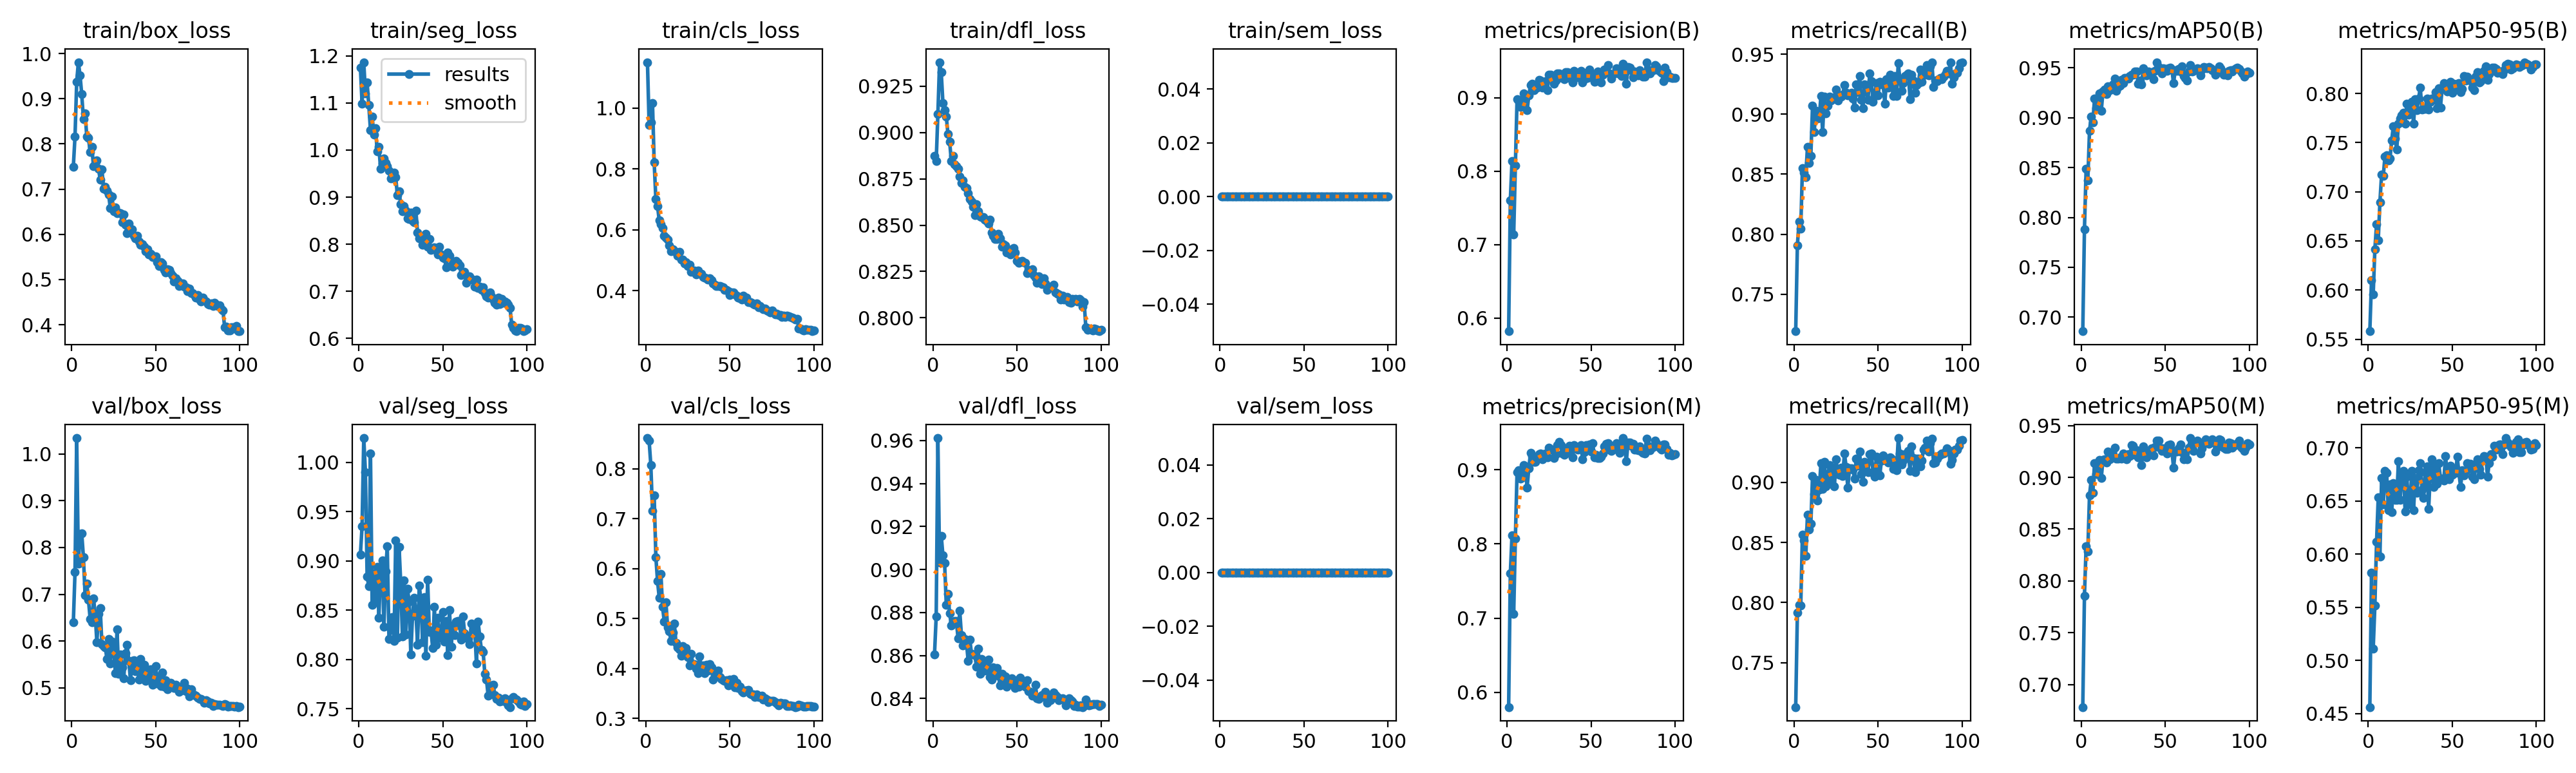

In [7]:
from IPython.display import Image, display

# Graficos de treino (losses + mAP ao longo dos epochs)
display(Image(filename=f"{RUN_DIR}/results.png", width=800))

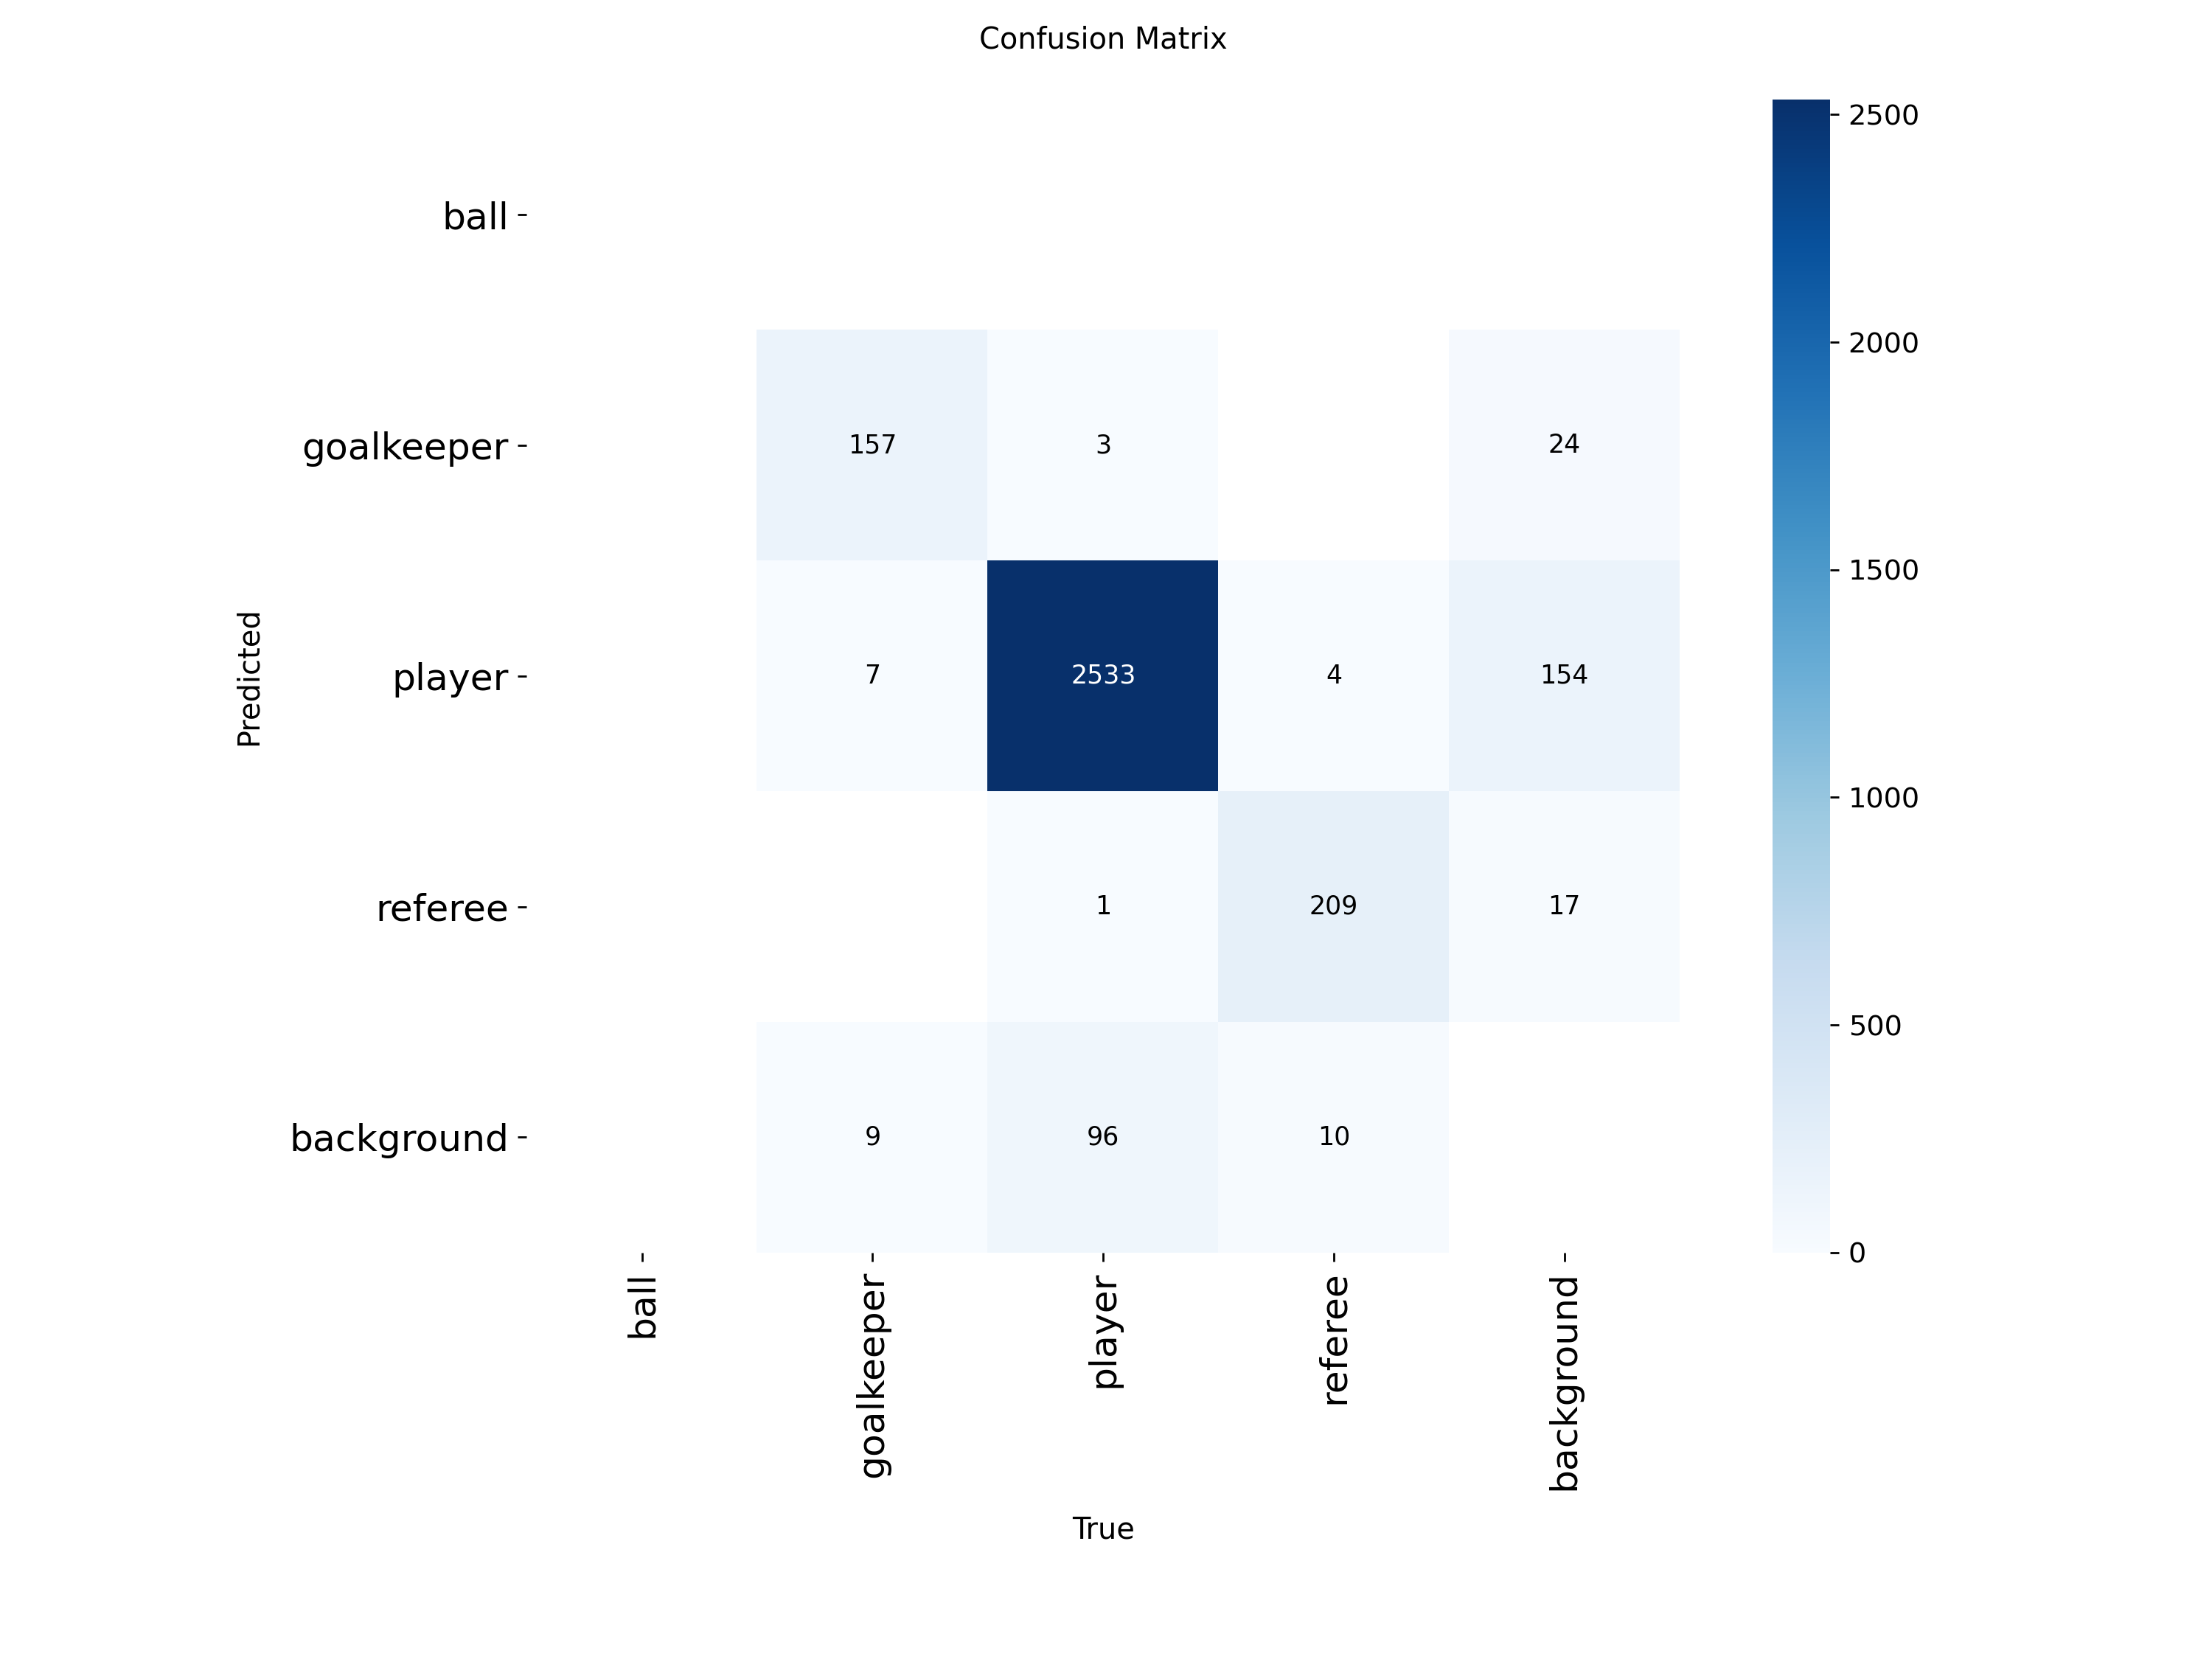

In [8]:
# Matriz de confusao
display(Image(filename=f"{RUN_DIR}/confusion_matrix.png", width=600))

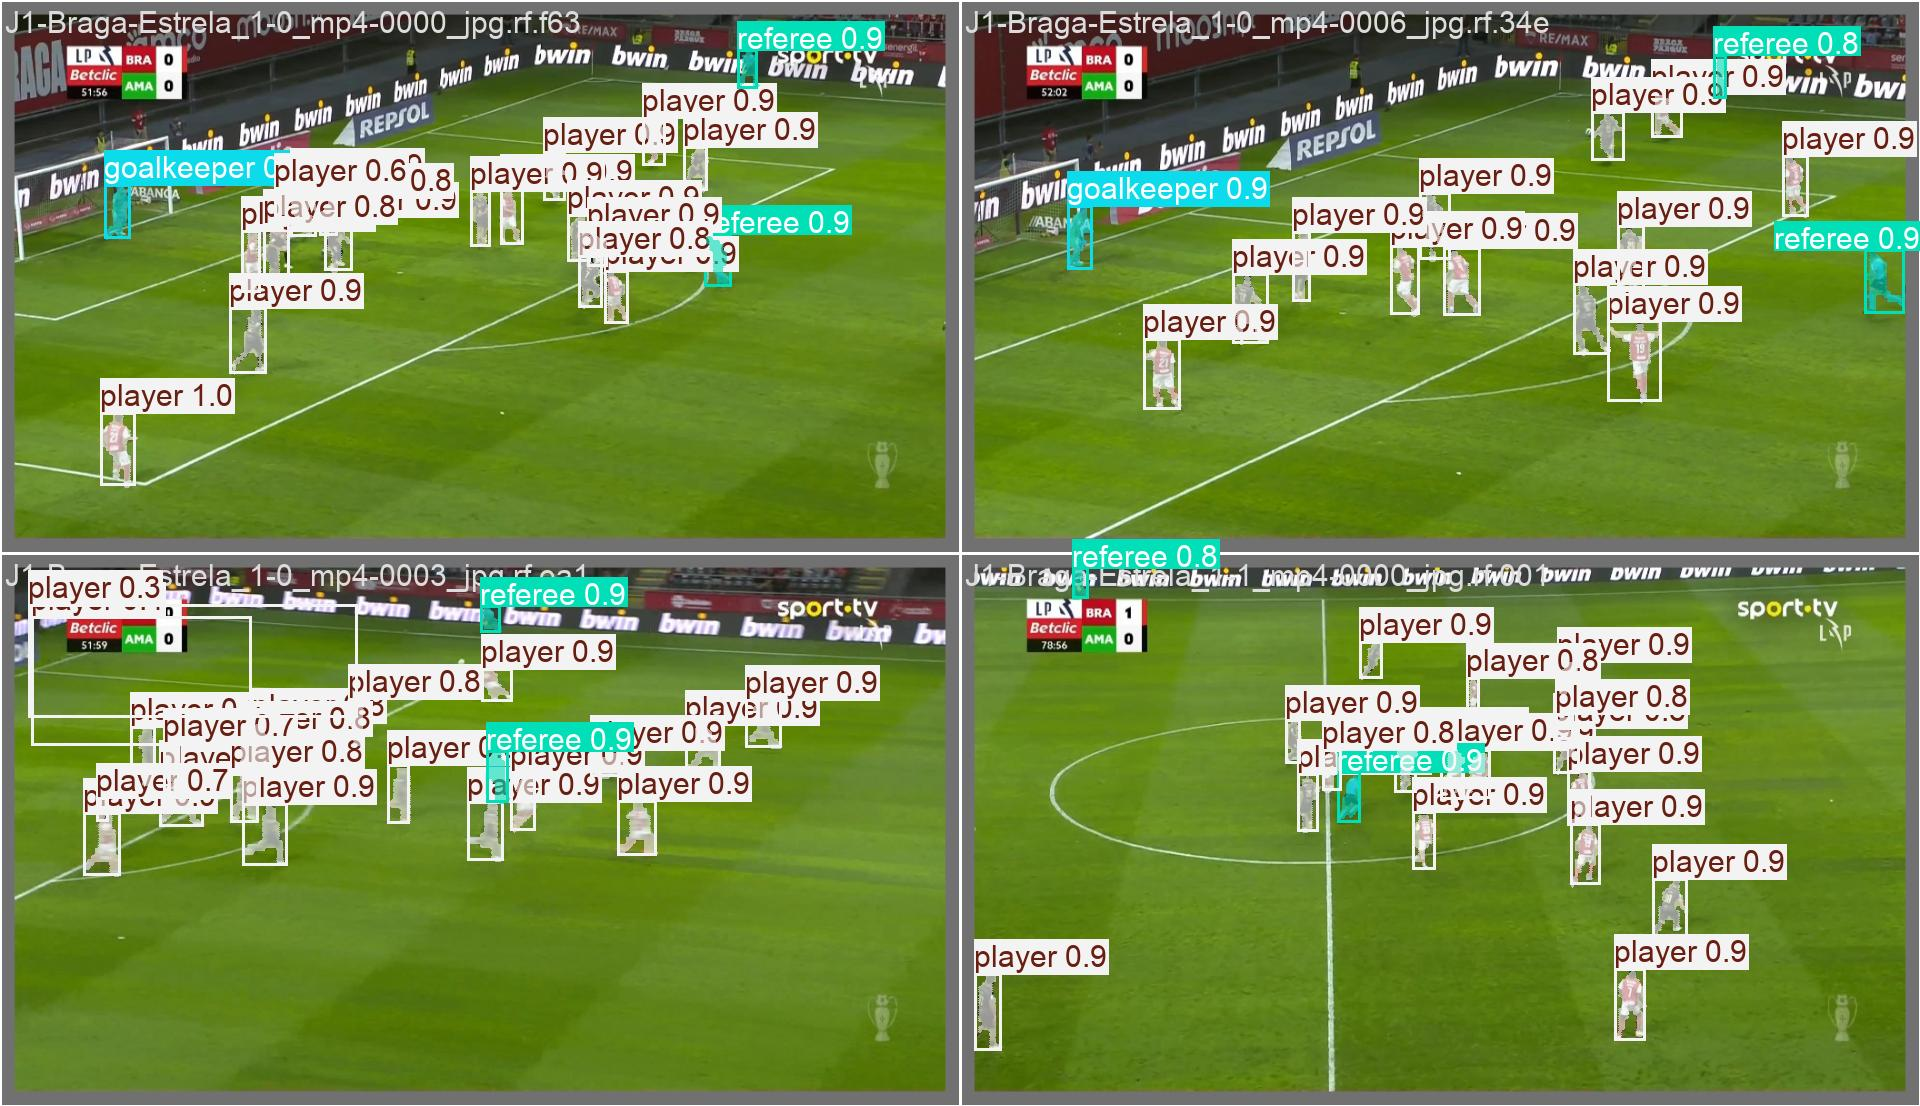

In [9]:
# Predicoes no batch de validacao (com mascaras de segmentacao)
display(Image(filename=f"{RUN_DIR}/val_batch0_pred.jpg", width=800))

## 5. Validacao Final

Validacao do melhor modelo com metricas de **Box** e **Mask** separadas.

Para segmentacao, o que nos interessa mais e o **Mask mAP** - indica a qualidade das mascaras.

In [10]:
# Validacao com metricas de Box E Mask
metrics = model.val(data=DATA_YAML, imgsz=640, batch=4, device=0, workers=0)

print("\n" + "=" * 60)
print("METRICAS DE DETECAO (Bounding Box)")
print("=" * 60)
print(f"  mAP50:    {metrics.box.map50:.3f} ({metrics.box.map50*100:.1f}%)")
print(f"  mAP50-95: {metrics.box.map:.3f} ({metrics.box.map*100:.1f}%)")

# Metricas de segmentacao (o que realmente nos interessa)
if hasattr(metrics, 'seg') and metrics.seg is not None:
    print("\n" + "=" * 60)
    print("METRICAS DE SEGMENTACAO (Mascara)")
    print("=" * 60)
    print(f"  Mask mAP50:    {metrics.seg.map50:.3f} ({metrics.seg.map50*100:.1f}%)")
    print(f"  Mask mAP50-95: {metrics.seg.map:.3f} ({metrics.seg.map*100:.1f}%)")

    # Metricas por classe
    if hasattr(metrics.seg, 'maps') and metrics.seg.maps is not None:
        class_names = data_config['names']
        print(f"\n  Por classe (Mask mAP50):")
        for i, map50 in enumerate(metrics.seg.maps):
            if i < len(class_names):
                print(f"    {class_names[i]:12s}: {map50:.3f} ({map50*100:.1f}%)")
else:
    print("\nATENCAO: Metricas de segmentacao nao disponiveis!")
    print("Verifica se o modelo e realmente yolo-seg e nao yolo-detect.")

Ultralytics 8.4.24  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11m-seg summary (fused): 139 layers, 22,338,396 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1826.2558.1 MB/s, size: 203.4 KB)
val: Scanning C:\_FOOTAR\PD_FOOTAR\training\datasets\player-ball-mask\valid\labels.cache... 202 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 202/202  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 8.5it/s 6.0s0.1s
                   all        202       3205      0.701      0.684      0.706      0.597      0.694      0.658      0.681       0.43
                  ball        175        176          0          0          0          0          0          0          0          0
            goalkeeper        173        173      0.913       0.89      0.922      0.753      0.927      0.867      0.90

## 6. Copiar modelo para producao

Copia o melhor modelo para `models/active/` onde os ficheiros main esperam encontra-lo.

In [11]:
import shutil

# Origem
best_weights = os.path.join(RUN_DIR, "weights", "best.pt")

# Destinos
PROJECT_ROOT = r"C:\_FOOTAR\PD_FOOTAR"
training_dest = os.path.join(PROJECT_ROOT, "training", "data", "yolo11m_seg_players.pt")
production_dest = os.path.join(PROJECT_ROOT, "models", "active", "yolo11m_seg_players.pt")

os.makedirs(os.path.dirname(training_dest), exist_ok=True)

# Copiar para training/data (backup)
shutil.copy2(best_weights, training_dest)
print(f"Copiado para treino:   {training_dest}")
print(f"  Tamanho: {os.path.getsize(training_dest) / (1024**2):.1f} MB")

# Copiar para models/active (producao)
shutil.copy2(best_weights, production_dest)
print(f"Copiado para producao: {production_dest}")
print(f"  Tamanho: {os.path.getsize(production_dest) / (1024**2):.1f} MB")

print("\n" + "=" * 60)
print("PROXIMO PASSO:")
print("  Atualizar PLAYER_DETECTION_MODEL_PATH no main para:")
print(f"  'models/active/yolo11m_seg_players.pt'")
print("  E usar result.masks no pipeline para obter mascaras")
print("=" * 60)

Copiado para treino:   C:\_FOOTAR\PD_FOOTAR\training\data\yolo11m_seg_players.pt
  Tamanho: 43.1 MB
Copiado para producao: C:\_FOOTAR\PD_FOOTAR\models\active\yolo11m_seg_players.pt
  Tamanho: 43.1 MB

PROXIMO PASSO:
  Atualizar PLAYER_DETECTION_MODEL_PATH no main para:
  'models/active/yolo11m_seg_players.pt'
  E usar result.masks no pipeline para obter mascaras


## 7. Teste rapido de inferencia com mascaras

Verifica que o modelo treinado produz mascaras de segmentacao corretamente.

In [12]:
import cv2
import numpy as np
from ultralytics import YOLO
from IPython.display import Image, display
import matplotlib.pyplot as plt

# Carregar modelo treinado
seg_model = YOLO(production_dest)

# Pegar uma imagem de teste
test_img_dir = os.path.join(DATASET_PATH, "test", "images")
test_images = os.listdir(test_img_dir)
test_img_path = os.path.join(test_img_dir, test_images[0])

# Inferencia
result = seg_model(test_img_path, imgsz=1024, conf=0.25, verbose=False)[0]

# Verificar se tem mascaras
if result.masks is not None:
    print(f"Mascaras encontradas: {len(result.masks)}")
    print(f"Shape das mascaras: {result.masks.data.shape}")
    print(f"Classes detetadas: {result.boxes.cls.tolist()}")
    print(f"Confidences: {[f'{c:.2f}' for c in result.boxes.conf.tolist()]}")

    # Visualizar resultado com mascaras
    annotated = result.plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    original = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis('off')
    axes[1].imshow(annotated_rgb)
    axes[1].set_title(f"Segmentacao ({len(result.masks)} mascaras)")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("ATENCAO: Modelo nao produziu mascaras!")
    print("Verifica se o modelo e yolo-seg e nao yolo-detect.")

Mascaras encontradas: 15
Shape das mascaras: torch.Size([15, 576, 1024])
Classes detetadas: [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 2.0, 2.0, 2.0, 2.0, 2.0, 1.0]
Confidences: ['0.94', '0.94', '0.93', '0.93', '0.93', '0.92', '0.92', '0.91', '0.90', '0.90', '0.90', '0.88', '0.87', '0.86', '0.86']


<Figure size 1600x600 with 2 Axes>

## 8. Exportar para TensorRT (.engine)

Compila o modelo treinado especificamente para a GPU onde estamos a correr (RTX 4060). 
O ficheiro `.engine` gerado substitui o `.pt` em producao e corre ~2-3x mais rapido, 
mantendo exatamente os mesmos pesos e a mesma precisao de detecao.

**Notas:**
- A exportacao demora ~5-10 min (compilacao otimizada para a GPU atual).
- O `.engine` e especifico desta GPU - se mudares de placa tens de re-exportar.
- `half=True` usa FP16 (tira partido dos Tensor Cores do RTX 4060).
- `imgsz=1024` tem de ser igual ao usado em producao (`main_seg.py`).

In [1]:
# Instalar TensorRT no venv (so corre se ainda nao estiver instalado)
try:
    import tensorrt
    print(f'tensorrt ja instalado: {tensorrt.__version__}')
except ImportError:
    print('A instalar tensorrt...')
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorrt'])
    import tensorrt
    print(f'tensorrt instalado: {tensorrt.__version__}')

A instalar tensorrt...
tensorrt instalado: 10.16.0.72


In [4]:
from ultralytics import YOLO
import os

# Caminho absoluto para o .pt (independente do cwd do notebook)
NB_DIR = os.getcwd()  # training/notebooks
PT_PATH = os.path.abspath(os.path.join(NB_DIR, '..', '..', 'models', 'active', 'yolo11m_seg_players.pt'))
print(f'Modelo de origem: {PT_PATH}')
assert os.path.exists(PT_PATH), f'Nao encontrado: {PT_PATH}'

model = YOLO(PT_PATH)

# Exportar para TensorRT FP16 @ imgsz=1024 (mesma resolucao usada no main_seg.py)
engine_path = model.export(
    format='engine',
    imgsz=1024,
    half=True,
    device=0,
    workspace=4,   # GB de workspace para otimizacao (RTX 4060 tem 8GB)
    verbose=True,
)

print(f'Engine gerado em: {engine_path}')
print('main_seg.py ja deteta o .engine automaticamente — basta correr como sempre.')

Modelo de origem: c:\_FOOTAR\PD_FOOTAR\models\active\yolo11m_seg_players.pt
Ultralytics 8.4.21  Python-3.12.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11m-seg summary (fused): 139 layers, 22,338,396 parameters, 0 gradients, 112.9 GFLOPs

PyTorch: starting from 'c:\_FOOTAR\PD_FOOTAR\models\active\yolo11m_seg_players.pt' with input shape (1, 3, 1024, 1024) BCHW and output shape(s) ((1, 40, 21504), (1, 32, 256, 256)) (43.1 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success  4.0s, saved as 'c:\_FOOTAR\PD_FOOTAR\models\active\yolo11m_seg_players.onnx' (85.8 MB)

TensorRT: starting export with TensorRT 10.16.0.72...
TensorRT: input "images" with shape(1, 3, 1024, 1024) DataType.FLOAT
TensorRT: output "output0" with shape(1, 40, 21504) DataType.FLOAT
Tensor